# Laboratorio # 2: LSTM

---

- Pedro Pablo Guzmán Mayen 22111
- Mathew Cordero 22982

---


Repositorio: [Repo](https://github.com/PedroPabloGuzmanMayen/Data_Science/tree/lab2)

---

## Introducción y resumen

Previamente se analizaron varias series de tiempo relacionadas con el precio, consumo e importaciones de varios hidrocarburos en Guatemala para generar modelos de predicción que fueran capaces de generar predicciones certadas sobre estos fenómenos. Los modelos fueron generados usando modelos como ARIMA o SARIMA. Ahora se pretende realizar otros modelos para predecir estos fenómenos utilizando técnicas de deep learining como redes neuronales recurrentes. 

# Objetivos

- Comparar el rendimiento de los modelos ARIMA y SARIMA con técnicas de deep learning y determinar cuál enfoque muestra un mejor desempeño. 
- Realizar modelos de predicción usando redes neuronale LSTM que sean capaces de predecir con precisión eventos futuros.
 

# Consumos

Se seleccionó la serie de consumos de gasolina regular a lo largo de los años para realizar los primeros modelos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
import statsmodels.api as sm

#Lectura y transformación de datos
pd.set_option('display.float_format', '{:.2f}'.format)

c2024 = pd.read_excel("./Data/Consumos_2024.xlsx", skiprows = 6, nrows = 300) #Solo 300 registros
c2025 = pd.read_excel("./Data/Consumos_2025.xlsx", skiprows = 6, nrows = 5)
precios = pd.read_excel("./Data/Precios_combustibles.xlsx", skiprows = 7, nrows = 195)
precios = precios.drop(precios.index[0]).reset_index(drop=True)
consumos = pd.concat([c2024, c2025], ignore_index= True)
i2024 = pd.read_excel("./Data/Importaciones_combustibles_2024.xlsx", skiprows = 6, nrows = 288)
i2025 = pd.read_excel("./Data/Importaciones_combustibles_2025.xlsx", skiprows = 6, nrows = 5)
for df in (i2024, i2025):
    df.columns = (
        df.columns
          .str.strip()      
          .str.lower()      
)
importaciones = pd.concat([i2024, i2025], ignore_index = True)
importaciones.loc[:203, 'diesel bajo azufre'] = importaciones.loc[:203, 'diesel alto azufre']
importaciones['Diesel'] = importaciones['diesel bajo azufre']
consumos.loc[:203, 'Diesel bajo azufre'] = consumos.loc[:203, 'Diesel alto azufre']
consumos['Diesel'] = consumos['Diesel bajo azufre']
consumos['Fecha'] = pd.to_datetime(consumos['Fecha']).dt.strftime('%Y-%m')
importaciones['Fecha'] = pd.to_datetime(consumos['Fecha']).dt.strftime('%Y-%m')




def graficar_histogramas_boxplot(dataframe, tipo_gasolina, titulo_hist, titulo_box ):
    sns.histplot(
    data=dataframe,
    x=tipo_gasolina,
    stat="density",
    kde=True,
    bins=30
    )
    plt.title(titulo_hist)
    plt.xlabel("Valor")
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()

    plt.figure()
    sns.boxplot(x=dataframe[tipo_gasolina])
    plt.title(titulo_box)
    plt.show()

def graficar_barras(dataset, xTitle, yTitle, generalTitle):
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(dataset.index, dataset.values, width=0.8)
    ax.set_xlabel(xTitle, fontsize=12)
    ax.set_ylabel(yTitle, fontsize=12)
    ax.set_title(generalTitle, fontsize=14, pad=15)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(dataset.index, rotation=45)
    plt.tight_layout()
    plt.show()


In [17]:

consumos.head()

,Fecha,Aceites lubricantes,Asfalto,Bunker,Ceras,Combustible turbo jet,Diesel bajo azufre,Diesel ultra bajo azufre,Gas licuado de petróleo,Gas natural,...,Mezclas\noleosas,Naftas,PetCoke,Petróleo crudo,Solventes,Butano,Diesel alto azufre,Orimulsión,Total,Diesel
0,2000-01,0.00,48446.00,296766.99,0.00,0.00,634667.06,0.00,194410.48,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,634667.06,0.00,1750544.64,634667.06
1,2000-02,0.00,50597.00,328116.44,0.00,0.00,642380.66,0.00,174710.55,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,642380.66,0.00,1773220.22,642380.66
2,2000-03,0.00,27593.00,368589.63,0.00,0.00,699807.25,0.00,189234.07,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,699807.25,0.00,1909498.79,699807.25
3,2000-04,0.00,53794.00,396300.47,0.00,0.00,586803.98,0.00,174330.61,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,586803.98,0.00,1800932.86,586803.98
4,2000-05,0.00,60137.00,449368.92,0.00,0.00,656948.20,0.00,191745.15,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,656948.20,0.00,1941771.90,656948.20


Ahora analizaremos la serie para determinar si es estacionaria y ver si debemos realizar algunas tranformaciones

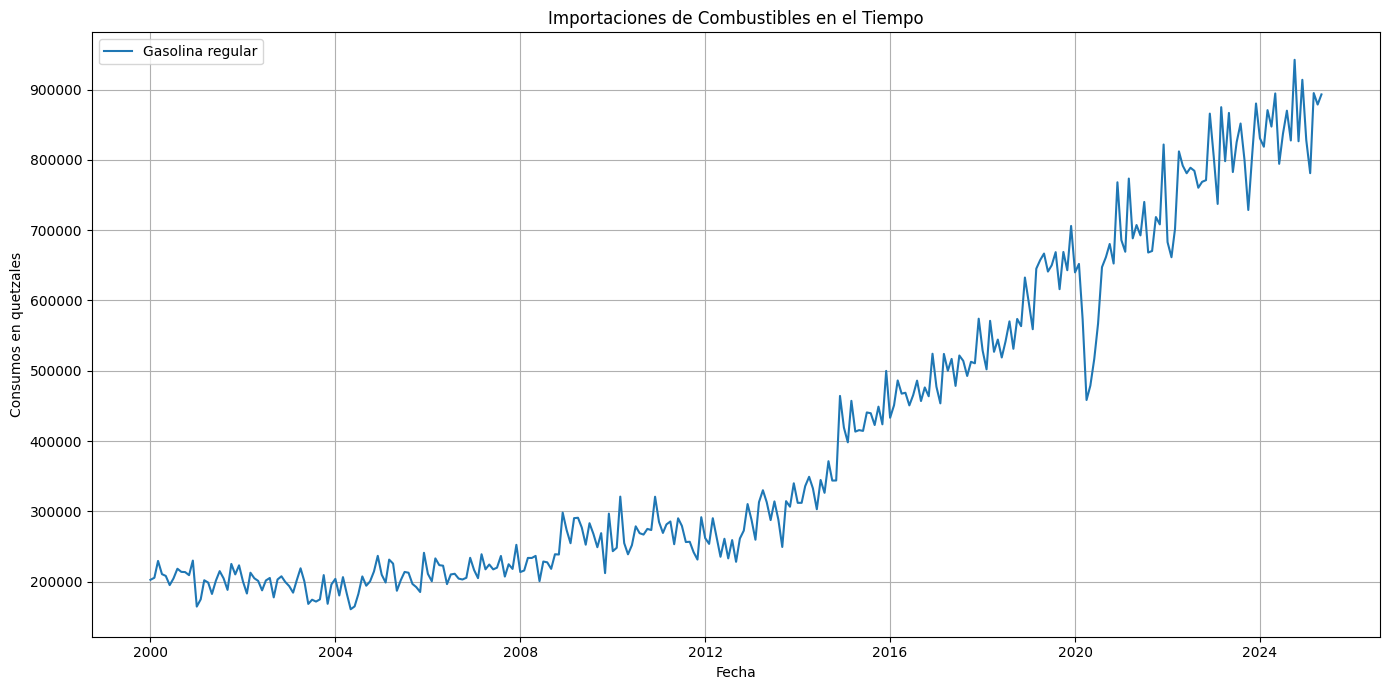

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

consumos['fecha'] = pd.to_datetime(consumos['Fecha'])

consumo_filtrado = consumos[['fecha', 'Gasolina regular']]

plt.figure(figsize=(14, 7))
plt.plot(consumo_filtrado['fecha'], consumo_filtrado['Gasolina regular'], label='Gasolina regular')

plt.title('Importaciones de Combustibles en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Consumos en quetzales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A simple vista, podemos ver que la serie muestra cierta tendencia y que la varianza no es constante, se realizarán diversos tests para determinar si las primeras impresiones de la serie son correctas. Vamos a empezar descomponiendo la serie

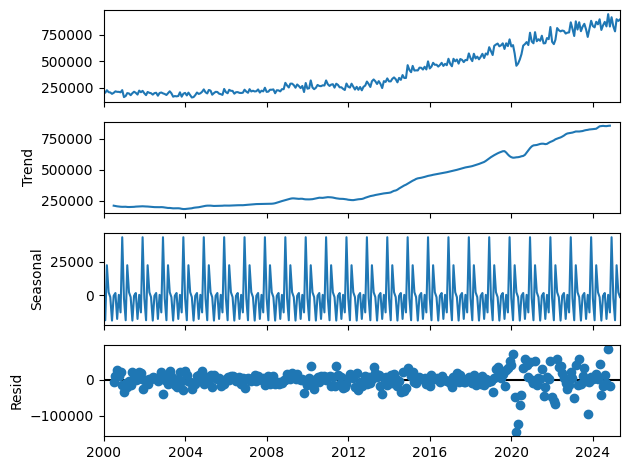

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
consumo_filtrado.set_index('fecha', inplace=True)

descomposicion = seasonal_decompose(consumo_filtrado)
descomposicion.plot();

Vemos que si hay tendencia y que la varianza no es constante, vamos a realizar el test de Fuller para confirmarlo´. 

In [20]:
from statsmodels.tsa.stattools import adfuller

print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(consumo_filtrado, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         2.29
p-value                       1.00
# de retardos usados         14.00
# de observaciones usadas   290.00
Critical Value (1%)          -3.45
Critical Value (5%)          -2.87
Critical Value (10%)         -2.57
dtype: float64


El p-value es mucho mayor a 0.05, esto confirma que la media no es estacionaria, se va  a diferenciar la serie y aplicar una tranformación logaritmica. 

In [21]:
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd

print('Resultados del Test de Dickey Fuller para log + diferenciación de la serie')


log_consumo = np.log(consumo_filtrado['Gasolina regular'])


ts_log_diff = log_consumo.diff().dropna()


dfTest = adfuller(ts_log_diff)


salidaDf = pd.Series(dfTest[0:4], index=[
    'Estadístico de prueba',
    'p-value',
    '# de retardos usados',
    '# de observaciones usadas'
])

for key, value in dfTest[4].items():
    salidaDf[f'Critical Value ({key})'] = value

print(salidaDf)

Resultados del Test de Dickey Fuller para log + diferenciación de la serie
Estadístico de prueba        -4.50
p-value                       0.00
# de retardos usados         16.00
# de observaciones usadas   287.00
Critical Value (1%)          -3.45
Critical Value (5%)          -2.87
Critical Value (10%)         -2.57
dtype: float64


Se redujo el p-value y ahora la serie tiene media constante, también aplicamos la tranformación logaritmica.

Ahora la serie se ve así:


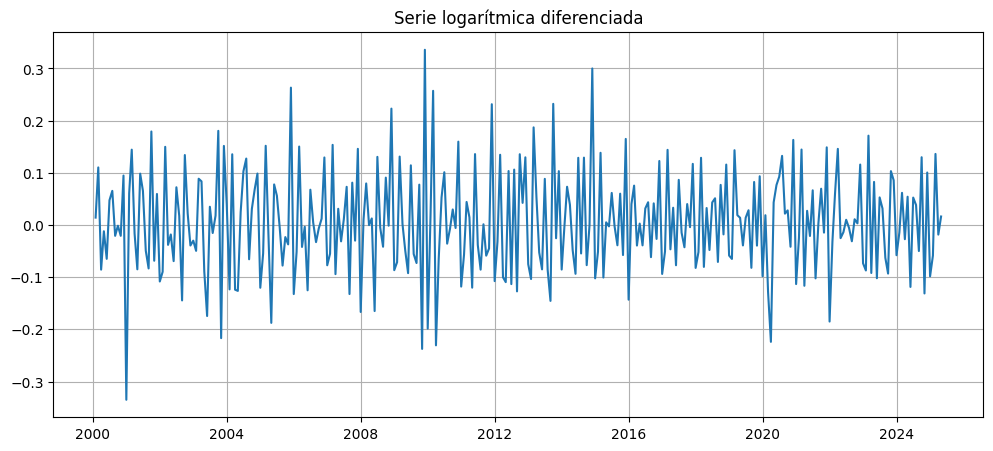

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(ts_log_diff)
plt.title("Serie logarítmica diferenciada")
plt.grid(True)
plt.show()

Se puede observar que la serie es estacionaria. Ahora se procederá a la construcción de los modelos.

## Modelos de predicción para los consumos de gasolina regular

Las redes neuronales trabajan mejor con los datos normalizados, por lo tanto primero se va a normalizar la serie.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
ts_log_diff_scaled = scaler.fit_transform(ts_log_diff.values.reshape(-1, 1))  # reshape necesario
print(ts_log_diff_scaled[1:7])

[[ 1.06921195]
 [-0.91721505]
 [-0.17133464]
 [-0.70742475]
 [ 0.43114982]
 [ 0.61410053]]


Ahora se crearán los conjuntos de entrenamiento y prueba. El 60% de los datos se usará para entrenamiento, 20% para validación y el 20% restante para pruebas. 

In [24]:
n = len(ts_log_diff_scaled)
entrenamiento = round(0.6 * n)
val_prueba = round(0.2 * n)


train = ts_log_diff_scaled[0:entrenamiento]
validation = ts_log_diff_scaled[entrenamiento:entrenamiento + val_prueba + 1]
test = ts_log_diff_scaled[(entrenamiento + val_prueba) - 1:]


train = np.insert(train, 0, 0)


train = train.reshape(-1, 1)
validation = validation.reshape(-1, 1)
test = test.reshape(-1, 1)

# Verificamos tamaños
print(f"Train: {len(train)}")
print(f"Validation: {len(validation)}")
print(f"Test: {len(test)}")

Train: 183
Validation: 62
Test: 62


La serie también va a ser convertida en una supervisada y se tendrá en cuenta que el dato anterior predice al siguiente.

In [25]:
from operator import concat


def supervisada(serie,retrasos = 1):
    serie_x = []
    serie_y = []
    for i in range(len(serie)-retrasos):
        valor = serie[i:(i+retrasos),0]
        valor_sig = serie[i+retrasos,0]
        serie_x.append(valor)
        serie_y.append(valor_sig)
    return np.array(serie_x), np.array(serie_y)

x_train,y_train = supervisada(train)
x_val,y_val = supervisada(validation)
x_test,y_test = supervisada(test)

In [26]:
x_train = np.reshape(x_train,(x_train.shape[0],1,1))
x_val = np.reshape(x_val, (x_val.shape[0],1,1))
x_test = np.reshape(x_test, (x_test.shape[0],1,1))
len(x_val)

61

### Primer modelo

El primer modelo tendrá estas características: 

- 1 capa LSTM con 50 unidades
- 1 capa de olvido con 20% de olvido
- 1 capa densa de salida
- Usará el optimizador de Adam

In [27]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

batch_size = 32 
timesteps = 12  
n_features = 1  
n_units = 50    

model = Sequential()


model.add(LSTM(units=n_units,
               stateful=False,
               input_shape=(timesteps, n_features),
               return_sequences=False)) 


model.add(Dropout(0.2))


model.add(Dense(1))


model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

e:\Data_Science\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='mean_squared_error',optimizer="rmsprop")

Ahora se va a realizar el entrenamiento del modelo. 

In [29]:
epocas = 50
history= model.fit(
    x = x_train,
    y = y_train,
    batch_size = batch_size,
    epochs = epocas,
    shuffle = False,
    validation_data = (x_val,y_val),
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 1.1107 - val_loss: 0.5720
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0882 - val_loss: 0.5623
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0743 - val_loss: 0.5545
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0685 - val_loss: 0.5477
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0520 - val_loss: 0.5414
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0407 - val_loss: 0.5355
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0288 - val_loss: 0.5300
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0249 - val_loss: 0.5250
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.0150 - val_loss: 0.5205
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0111 - val_loss: 0.5164
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0059 - val_loss: 0.5127
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9985 - val_loss: 0.5095
E

Ahora se analizara la pérdida obtenida en el conjunto de entrenamiento y en el de validación en cada época.

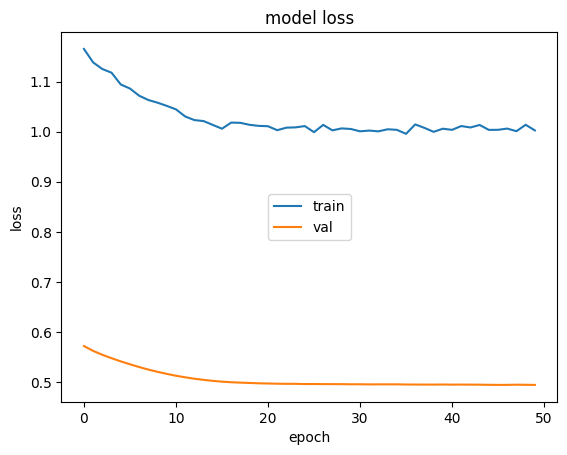

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center')

La pérdida con el conjunto de validación es bastante baja, sin embargo en e conjutno de prueba la pérdida no llegó a ser menor que 1. El siguiente paso es realizar la predicción con este modelo

In [31]:
prediccion_val = []

def prediccion_fun(data,modelo, batch_size,scaler,dif=False,dif_cant=1, Series = None , n=1):
    prediccion = [0]* (len(data))
    i=0
    for X in data:
        X = np.reshape(X,(1,1,1))
        yhat = modelo.predict(X, batch_size=batch_size,verbose=0)
        # invert scaling
        yhat = scaler.inverse_transform(yhat)
        if dif:
             # invert differencing
            yhat  = yhat + Series[(n+dif_cant*i)]
        # store
        prediccion[i]=yhat[0][0]
        i = i+1
    return prediccion
prediccion_val = prediccion_fun(x_val,model, 1,scaler,dif=True,dif_cant=1, Series = consumo_filtrado.values , n=entrenamiento)
prediccion_test = prediccion_fun(x_test,model, 1,scaler,dif=True,dif_cant=1, Series = consumo_filtrado.values , n=entrenamiento+val_prueba)

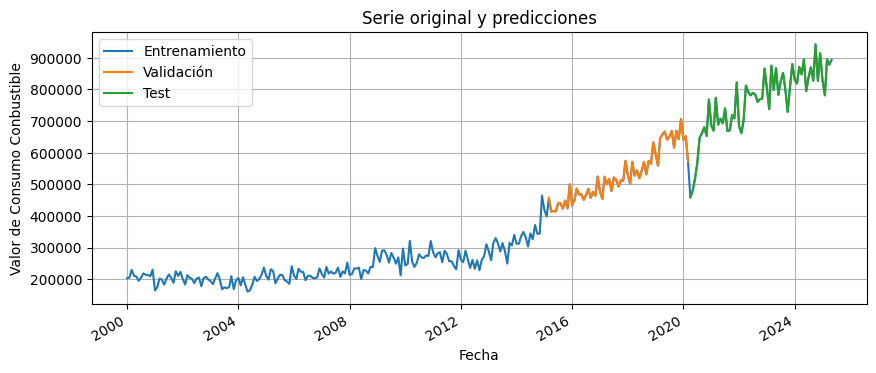

In [32]:
df_val = pd.DataFrame(prediccion_val,index=consumo_filtrado[(entrenamiento):entrenamiento+val_prueba].index)
start_test = entrenamiento + len(df_val)
end_test = start_test + len(prediccion_test)

df_test = pd.DataFrame(prediccion_test, index=consumo_filtrado[start_test:end_test].index)




plt.figure(figsize=(10,4))
plt.plot(consumo_filtrado,        label='Entrenamiento')
plt.plot(df_val,    label='Validación')

plt.plot(df_test,   label='Test')

plt.title('Serie original y predicciones')
plt.xlabel('Fecha')
plt.ylabel('Valor de Consumo Conbustible')
plt.grid(True)
plt.legend(loc='upper left')

plt.gcf().autofmt_xdate()
plt.show()

La gráfica muestra que las predicciones realizadas son bastante precisas, ahora se analizarán las métricas del modelo. 

In [33]:
print("Pérdida en Entrenamiento")                              # opcional, para limpiar estados previos
train_loss = model.evaluate(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    verbose=1
)

print("\nPérdida en Validación")
val_loss = model.evaluate(
    x=x_val,
    y=y_val,
    batch_size=batch_size,
    verbose=1
)


print("Pérdida en prueba")
val_loss = model.evaluate(
    x=x_test,
    y=y_test,
    batch_size=batch_size,
    verbose=1
)

Pérdida en Entrenamiento
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9783  

Pérdida en Validación
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4433
Pérdida en prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6152


El rendimiento del modelo es aceptable pero con un tuneo de parámetros podría mejorarse. Se va a realizar un segundo modelo con mejores parámetros. 

#### AIC y BIC

In [34]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calcular_mse_aic_bic(modelo, x_data, y_data, nombre=""):
    
    if len(x_data.shape) == 2:
        x_data = x_data.reshape(x_data.shape[0], 1, 1)
    elif len(x_data.shape) == 1:
        x_data = x_data.reshape(-1, 1, 1)
    
    
    y_pred = modelo.predict(x_data, verbose=0)
    
    
    y_pred = y_pred.flatten()
    y_true = y_data.flatten()
    
    
    n = len(y_true)  # número de observaciones
    mse = mean_squared_error(y_true, y_pred)
    k = modelo.count_params()  # número de parámetros
    
    
    if mse <= 0:
        mse = 1e-10
    
    log_likelihood = -n/2 * np.log(2 * np.pi) - n/2 * np.log(mse) - (n/2)
    
    # Calcular AIC y BIC
    aic = 2 * k - 2 * log_likelihood
    bic = np.log(n) * k - 2 * log_likelihood
    
    # Mostrar resultados
    print(f"\n{nombre.upper()}:")
    print(f"  Observaciones (n): {n}")
    print(f"  Parámetros (k): {k:,}")
    print(f"  MSE: {mse:.8f}")
    print(f"  AIC: {aic:.2f}")
    print(f"  BIC: {bic:.2f}")
    
    return mse, aic, bic

# CALCULAR PARA TODOS LOS CONJUNTOS
print("CALCULANDO MSE, AIC Y BIC PARA TU MODELO LSTM")
print("=" * 50)

# Entrenamiento
mse_train, aic_train, bic_train = calcular_mse_aic_bic(model, x_train, y_train, "Entrenamiento")

# Validación  
mse_val, aic_val, bic_val = calcular_mse_aic_bic(model, x_val, y_val, "Validación")

# Prueba
mse_test, aic_test, bic_test = calcular_mse_aic_bic(model, x_test, y_test, "Prueba")

# Resumen final
print("\n" + "=" * 50)
print("RESUMEN COMPARATIVO:")
print("=" * 50)
print(f"{'Conjunto':<15} {'MSE':<12} {'AIC':<8} {'BIC':<8}")
print("-" * 50)
print(f"{'Entrenamiento':<15} {mse_train:<12.6f} {aic_train:<8.0f} {bic_train:<8.0f}")
print(f"{'Validación':<15} {mse_val:<12.6f} {aic_val:<8.0f} {bic_val:<8.0f}")
print(f"{'Prueba':<15} {mse_test:<12.6f} {aic_test:<8.0f} {bic_test:<8.0f}")
print("=" * 50)

print("\nINTERPRETACIÓN:")
print("• MSE más bajo = mejor predicción")
print("• AIC más bajo = mejor modelo para predicción") 
print("• BIC más bajo = mejor modelo considerando complejidad")
print("• Para evaluación final, usa las métricas de VALIDACIÓN")

# Guardar en diccionario si quieres usar después
resultados = {
    'entrenamiento': {'mse': mse_train, 'aic': aic_train, 'bic': bic_train},
    'validacion': {'mse': mse_val, 'aic': aic_val, 'bic': bic_val},
    'prueba': {'mse': mse_test, 'aic': aic_test, 'bic': bic_test}
}

print(f"\nVALORES CLAVE PARA TU MODELO:")
print(f"• MSE validación: {mse_val:.6f}")
print(f"• AIC validación: {aic_val:.0f}")
print(f"• BIC validación: {bic_val:.0f}")

CALCULANDO MSE, AIC Y BIC PARA TU MODELO LSTM

ENTRENAMIENTO:
  Observaciones (n): 182
  Parámetros (k): 10,451
  MSE: 1.00321799
  AIC: 21419.08
  BIC: 54904.15

VALIDACIÓN:
  Observaciones (n): 61
  Parámetros (k): 10,451
  MSE: 0.49433091
  AIC: 21032.13
  BIC: 43092.88

PRUEBA:
  Observaciones (n): 61
  Parámetros (k): 10,451
  MSE: 0.59481817
  AIC: 21043.42
  BIC: 43104.16

RESUMEN COMPARATIVO:
Conjunto        MSE          AIC      BIC     
--------------------------------------------------
Entrenamiento   1.003218     21419    54904   
Validación      0.494331     21032    43093   
Prueba          0.594818     21043    43104   

INTERPRETACIÓN:
• MSE más bajo = mejor predicción
• AIC más bajo = mejor modelo para predicción
• BIC más bajo = mejor modelo considerando complejidad
• Para evaluación final, usa las métricas de VALIDACIÓN

VALORES CLAVE PARA TU MODELO:
• MSE validación: 0.494331
• AIC validación: 21032
• BIC validación: 43093


### Modelo 2: Consumos de gasolina regular

Este segundo modelo tendrá estas características:

- Una capa bidireccional de 64 unidades de procesamiento: va a permitir capturas más dependencias dentro de la secuencia debido a que analiza el input de principio a fin y viceversa. 

In [23]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional

batch_size = 32
timesteps = 12
n_features = 1

model2 = Sequential()


model2.add(Bidirectional(LSTM(units=64, return_sequences=True),
                        input_shape=(timesteps, n_features)))
model2.add(Dropout(0.3))
model2.add(BatchNormalization())


model2.add(LSTM(units=32, return_sequences=False))
model2.add(Dropout(0.3))


model2.add(Dense(16, activation='elu'))
model2.add(Dropout(0.2))


model2.add(Dense(1))


model2.compile(optimizer='RMSprop', loss='mean_squared_error')

model2.summary()

c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,457 (216.63 KB)

 Trainable params: 55,201 (215.63 KB)

 Non-trainable params: 256 (1.00 KB)

In [25]:
model2.compile(loss='mean_squared_error',optimizer="rmsprop")

Ahora se entranará el nuevo modelo

In [32]:

history_2= model2.fit(
    x = x_train,
    y = y_train,
    batch_size = batch_size,
    epochs = epocas,
    shuffle = False,
    validation_data = (x_val,y_val),
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9579 - val_loss: 0.5150
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9901 - val_loss: 0.5100
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0180 - val_loss: 0.5099
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9761 - val_loss: 0.5126
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0142 - val_loss: 0.5114
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0018 - val_loss: 0.5104
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9966 - val_loss: 0.5148
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9513 - val_loss: 0.5141
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9981 - val_loss: 0.5074
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0306 - val_loss: 0.5060
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9751 - val_loss: 0.5061
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9841 - val_loss: 0.5062
Epoch 13/

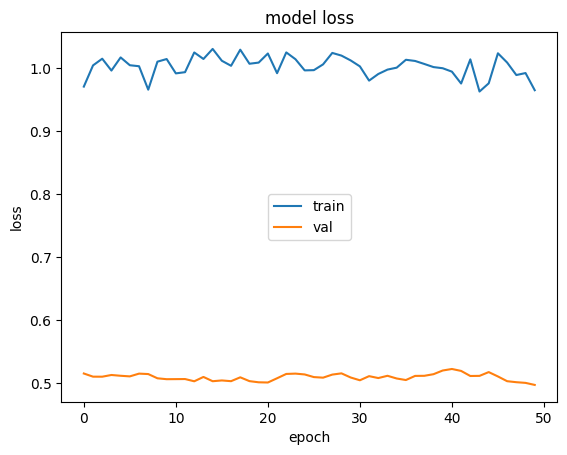

In [33]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center')

Se redujo la pérdida del modelo anterior en el conjunto de validación, la pérdida en el conjunto de pérdida llegó a ser menor que 1 pero no es una diferencia significativa con respecto al modelo anterior. Ahora se realizarán las predicciones con este modelo.

In [34]:
prediccion_val2 = []

def prediccion_fun(data,modelo, batch_size,scaler,dif=False,dif_cant=1, Series = None , n=1):
    prediccion = [0]* (len(data))
    i=0
    for X in data:
        X = np.reshape(X,(1,1,1))
        yhat = modelo.predict(X, batch_size=batch_size,verbose=0)
        # invert scaling
        yhat = scaler.inverse_transform(yhat)
        if dif:
             # invert differencing
            yhat  = yhat + Series[(n+dif_cant*i)]
        # store
        prediccion[i]=yhat[0][0]
        i = i+1
    return prediccion
prediccion_val2 = prediccion_fun(x_val,model2, 1,scaler,dif=True,dif_cant=1, Series = consumo_filtrado.values , n=entrenamiento)
prediccion_test2 = prediccion_fun(x_test,model2, 1,scaler,dif=True,dif_cant=1, Series = consumo_filtrado.values , n=entrenamiento+val_prueba)


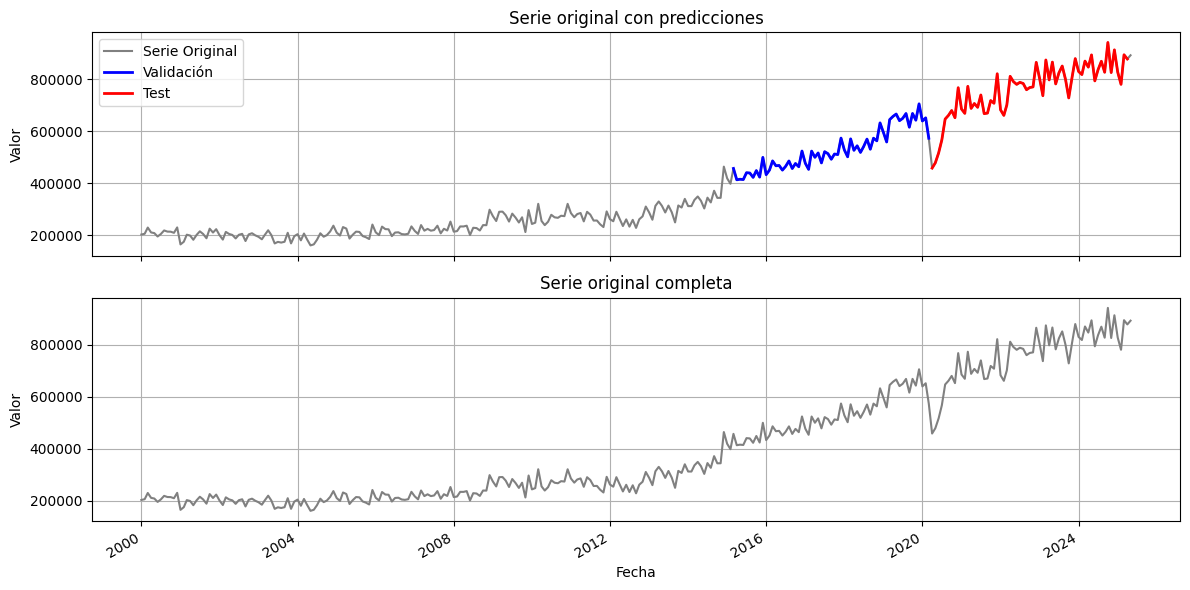

In [35]:

df_val2 = pd.DataFrame(prediccion_val2, 
                       index=consumo_filtrado[entrenamiento:entrenamiento+val_prueba].index)

start_test2 = entrenamiento + len(df_val2)
end_test2 = start_test2 + len(prediccion_test2)

df_test2 = pd.DataFrame(prediccion_test2, 
                        index=consumo_filtrado[start_test2:end_test2].index)


fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)


axs[0].plot(consumo_filtrado, color='gray', label='Serie Original')
axs[0].plot(df_val2, color='blue', label='Validación', linewidth=2)
axs[0].plot(df_test2, color='red', label='Test', linewidth=2)
axs[0].set_title('Serie original con predicciones')
axs[0].set_ylabel('Valor')
axs[0].grid(True)
axs[0].legend(loc='upper left')


axs[1].plot(consumo_filtrado, color='gray')
axs[1].set_title('Serie original completa')
axs[1].set_xlabel('Fecha')
axs[1].set_ylabel('Valor')
axs[1].grid(True)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [36]:
print("Pérdida en Entrenamiento")                              # opcional, para limpiar estados previos
train_loss2 = model2.evaluate(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    verbose=1
)

print("\nPérdida en Validación")
val_loss2 = model2.evaluate(
    x=x_val,
    y=y_val,
    batch_size=batch_size,
    verbose=1
)


print("Pérdida en prueba")
val_loss2 = model2.evaluate(
    x=x_test,
    y=y_test,
    batch_size=batch_size,
    verbose=1
)

Pérdida en Entrenamiento
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9828 

Pérdida en Validación
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4426
Pérdida en prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6077


Las gráficas muestran que este modelo tuvo un rendimiento bastante similar al anterior, no hay diferencia significativa entre los modelos. 

# Precios

Ahora se analizará la serie de precios de la gasolina regular en 2025. Primero se exportaraán y limpiaran los datos. 

In [2]:
# Lectura y limpieza del conjunto de datos
import pandas as pd
import matplotlib.pyplot as plt
precios = pd.read_excel("./Data/Precios_combustibles.xlsx", skiprows = 7, nrows = 195)
precios = precios.drop(precios.index[0]).reset_index(drop=True)
precios['FECHA'] = pd.to_datetime(precios['FECHA'])

precios.head()

,FECHA,Tipo de Cambio,Superior,Regular,Diesel,Bunker,Glp Cilindro 25Lbs.,Unnamed: 7
0,2025-01-01,7.70625,28.95,27.45,25.47,18.74,110,4.4
1,2025-01-02,7.7074,28.95,27.45,25.47,18.74,110,4.4
2,2025-01-03,7.70971,28.95,27.45,25.47,18.74,110,4.4
3,2025-01-04,7.70971,28.95,27.45,25.47,18.74,110,4.4
4,2025-01-05,7.70971,28.95,27.45,25.47,18.74,110,4.4


Ahora se analizará la serie para determinar si se deben realizar tranformaciones para que los modelos funcionen de forma correcta. 

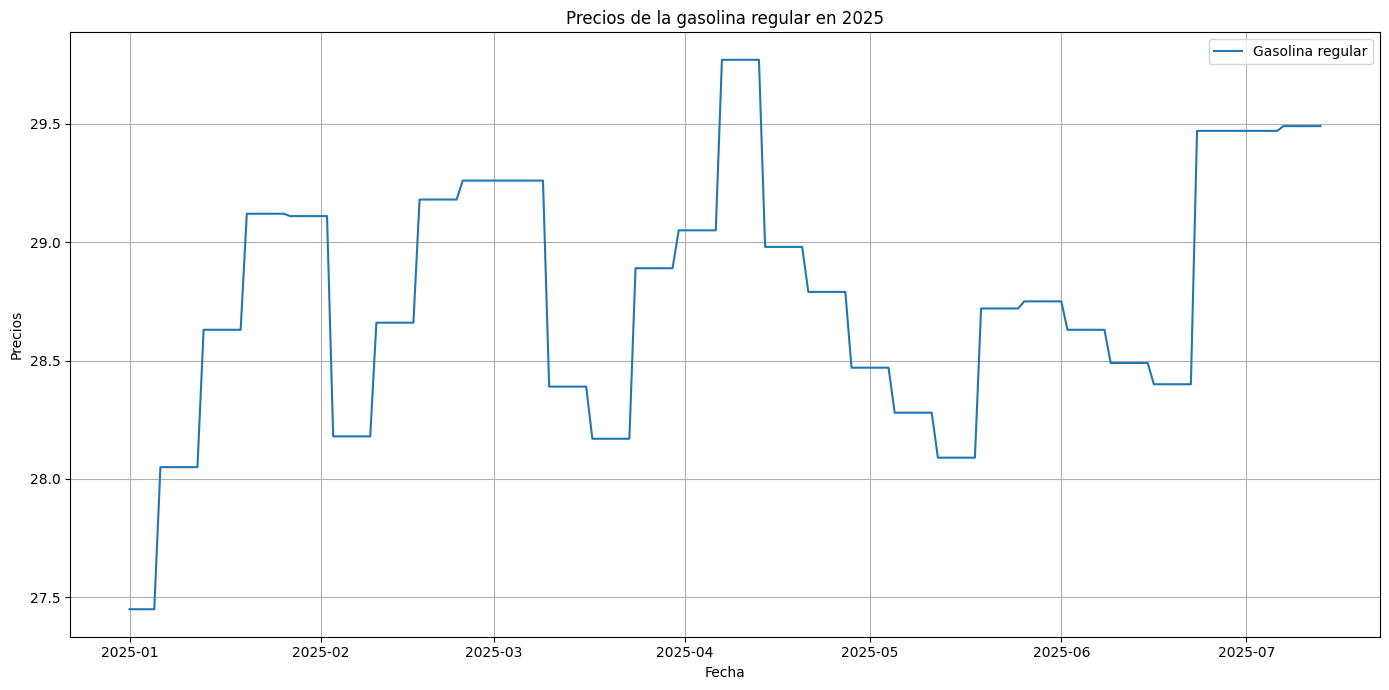

In [3]:
precios_regular = precios[['FECHA', 'Regular']]
precios_regular

plt.figure(figsize=(14, 7))
plt.plot(precios_regular['FECHA'], precios_regular['Regular'], label='Gasolina regular')

plt.title('Precios de la gasolina regular en 2025')
plt.xlabel('Fecha')
plt.ylabel('Precios')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

A simple vista se ve que la serie es estacionaria, se realizará el test de Fuller y el análisis de componentes para determinar si la suposición es verdadera. 

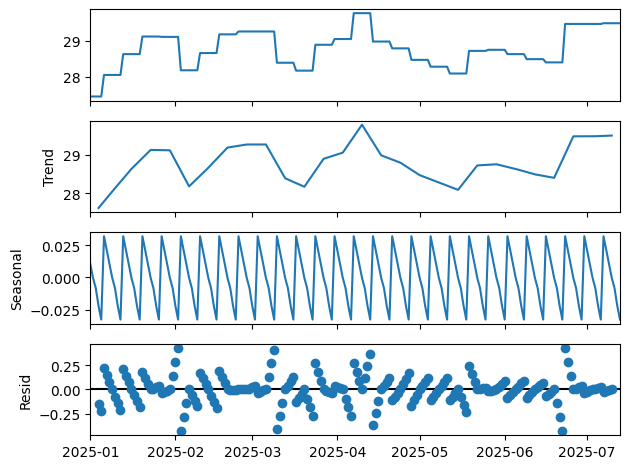

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
precios_regular.set_index('FECHA', inplace=True)

descomposicion = seasonal_decompose(precios_regular)
descomposicion.plot();

No se nota una tendencia pero la varianza no es constante. 

In [5]:
from statsmodels.tsa.stattools import adfuller

print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(precios_regular, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         -3.051074
p-value                        0.030392
# de retardos usados           0.000000
# de observaciones usadas    193.000000
Critical Value (1%)           -3.464694
Critical Value (5%)           -2.876635
Critical Value (10%)          -2.574816
dtype: float64


El test de Fuller muestra que la serie es estacionaria pues el p-value no es mayor que 0.05, por lo tanto no se aplicaran tranformaciones a la serie. Antes de contruir los modelos se estandarizará la serie y se crearán los modelos de entrenamient, validación y prueba, se usarán la misma configuración que en la serie de consumos. 

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
precios_escalados = scaler.fit_transform(precios_regular.values.reshape(-1, 1))  # reshape necesario
print(precios_escalados[1:7])

[[-2.59105265]
 [-2.59105265]
 [-2.59105265]
 [-2.59105265]
 [-1.41385309]
 [-1.41385309]]


In [7]:

import numpy as np
n = len(precios_escalados)
entrenamiento = round(0.6 * n)
val_prueba = round(0.2 * n)


train = precios_escalados[0:entrenamiento]
validation = precios_escalados[entrenamiento:entrenamiento + val_prueba + 1]
test = precios_escalados[(entrenamiento + val_prueba) - 1:]


train = np.insert(train, 0, 0)


train = train.reshape(-1, 1)
validation = validation.reshape(-1, 1)
test = test.reshape(-1, 1)

# Verificamos tamaños
print(f"Entrenamiento: {len(train)}")
print(f"Validación: {len(validation)}")
print(f"Prueba: {len(test)}")

Entrenamiento: 117
Validación: 40
Prueba: 40


In [8]:
from operator import concat


def supervisada(serie,retrasos = 1):
    serie_x = []
    serie_y = []
    for i in range(len(serie)-retrasos):
        valor = serie[i:(i+retrasos),0]
        valor_sig = serie[i+retrasos,0]
        serie_x.append(valor)
        serie_y.append(valor_sig)
    return np.array(serie_x), np.array(serie_y)

x_train,y_train = supervisada(train)
x_val,y_val = supervisada(validation)
x_test,y_test = supervisada(test)

### Primer modelo

El modelo inicial tendrá estas características: 

- 2 capas LSTM las cuáles serán útiles para comprender de mejor forma los patrones a lo largo del tiempo. 
- 1 capa de olvido con 0.2 la cuál ayudará a prevenir overfitting
- 2 capas densas, la primera ayudará a entender los patrones recolectados en las capas LSTM, la última será el output final.

In [9]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

batch_size = 32 #Vamos a usar 32 de batchsize
timesteps = 1 #Porque solo tendremos como entrada un día  
n_features = 1  # Porque la variable de salida solo es el precio del siguiente día. 
n_units = 64 #Usaremos 64 unidades de procesamiento en este modelo inicial 

model = Sequential()


model.add(LSTM(units=n_units,
               stateful=False,
               input_shape=(timesteps, n_features),
               return_sequences=True)) 


model.add(LSTM(units=n_units,
               stateful=False,
               input_shape=(timesteps, n_features),
               return_sequences=False)) #Segunda capa LSTM


model.add(Dense(128, activation="relu")) # Nos ayuda a comprender mejor los patrones encontrados anteriormente, tendrá una relu como activación

model.add(Dropout(0.20))
model.add(Dense(1)) #Capa de salida.


model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

e:\Data_Science\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Ahora se realizará el entrenamiento usando 150 épocas. 

In [10]:
epocas = 150
history= model.fit(
    x = x_train,
    y = y_train,
    batch_size = batch_size,
    epochs = epocas,
    shuffle = False,
    validation_data = (x_val,y_val),
    verbose=1
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - loss: 1.2115 - val_loss: 0.5394
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.1702 - val_loss: 0.5318
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.1414 - val_loss: 0.5211
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.1057 - val_loss: 0.5052
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0600 - val_loss: 0.4835
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.0146 - val_loss: 0.4558
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9431 - val_loss: 0.4211
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8625 - val_loss: 0.3795
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7752 - val_loss: 0.3302
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6827 - val_loss: 0.2738
Epoch 11/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5963 - val_loss: 0.2126
Epoch 12/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4791 - val_l

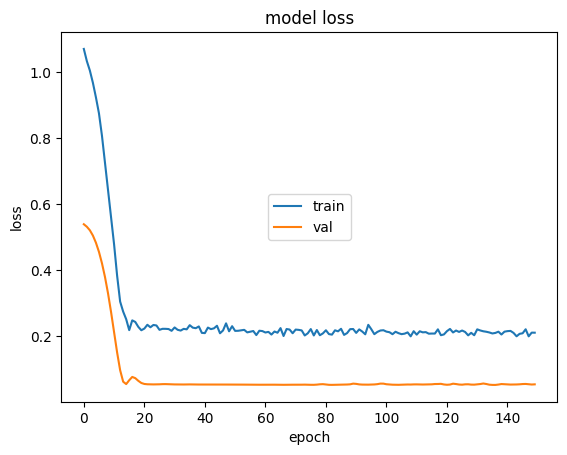

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center')

El modelo muestra pérdidas bastante aceptables en ambos conjuntos de entrenamiento pues son cercanas a 0, ahora se realizarán las predicciones. 

In [12]:
prediccion_val = []

def prediccion_fun(data,modelo, batch_size,scaler,dif=False,dif_cant=1, Series = None , n=1):
    prediccion = [0]* (len(data))
    i=0
    for X in data:
        X = np.reshape(X,(1,1,1))
        yhat = modelo.predict(X, batch_size=batch_size,verbose=0)
        # invert scaling
        yhat = scaler.inverse_transform(yhat)
        if dif:
             # invert differencing
            yhat  = yhat + Series[(n+dif_cant*i)]
        # store
        prediccion[i]=yhat[0][0]
        i = i+1
    return prediccion
prediccion_val = prediccion_fun(x_val,model, 1,scaler,dif=False,dif_cant=0, Series = precios_regular.values , n=entrenamiento)
prediccion_test = prediccion_fun(x_test,model, 1,scaler,dif=False,dif_cant=0, Series = precios_regular.values , n=entrenamiento+val_prueba)

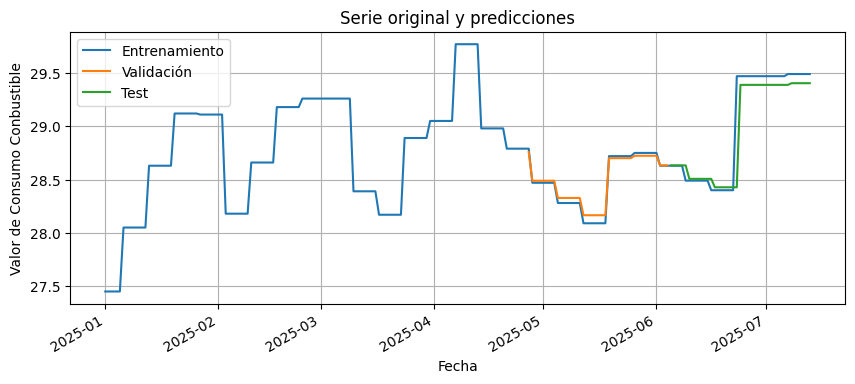

In [13]:
df_val = pd.DataFrame(prediccion_val,index=precios_regular[(entrenamiento):entrenamiento+val_prueba].index)
start_test = entrenamiento + len(df_val)
end_test = start_test + len(prediccion_test)

df_test = pd.DataFrame(prediccion_test, index=precios_regular[start_test:end_test].index)




plt.figure(figsize=(10,4))
plt.plot(precios_regular,        label='Entrenamiento')
plt.plot(df_val,    label='Validación')

plt.plot(df_test,   label='Test')

plt.title('Serie original y predicciones')
plt.xlabel('Fecha')
plt.ylabel('Valor de Consumo Conbustible')
plt.grid(True)
plt.legend(loc='upper left')

plt.gcf().autofmt_xdate()
plt.show()

In [14]:
print("Pérdida en Entrenamiento")                              # opcional, para limpiar estados previos
train_loss = model.evaluate(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    verbose=1
)

print("\nPérdida en Validación")
val_loss = model.evaluate(
    x=x_val,
    y=y_val,
    batch_size=batch_size,
    verbose=1
)


print("Pérdida en prueba")
val_loss = model.evaluate(
    x=x_test,
    y=y_test,
    batch_size=batch_size,
    verbose=1
)

Pérdida en Entrenamiento
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2282

Pérdida en Validación
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0587
Pérdida en prueba
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1319


La gráfica muestra que las predicciones son bastante cercanas a los valores reales y las métricas niveles de pérdida son bastante cercanos a 0 en cada uno de los conjuntos de datos, podemos decir que este modelo tiene un rendimiento bastante aceptable y que sus predicciones son bastante acertadas. 

#### AIC y BIC

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calcular_mse_aic_bic(modelo, x_data, y_data, nombre=""):
    
    if len(x_data.shape) == 2:
        x_data = x_data.reshape(x_data.shape[0], 1, 1)
    elif len(x_data.shape) == 1:
        x_data = x_data.reshape(-1, 1, 1)
    
    
    y_pred = modelo.predict(x_data, verbose=0)
    
    
    y_pred = y_pred.flatten()
    y_true = y_data.flatten()
    
    
    n = len(y_true)  # número de observaciones
    mse = mean_squared_error(y_true, y_pred)
    k = modelo.count_params()  # número de parámetros
    
    
    if mse <= 0:
        mse = 1e-10
    
    log_likelihood = -n/2 * np.log(2 * np.pi) - n/2 * np.log(mse) - (n/2)
    
    # Calcular AIC y BIC
    aic = 2 * k - 2 * log_likelihood
    bic = np.log(n) * k - 2 * log_likelihood
    
    # Mostrar resultados
    print(f"\n{nombre.upper()}:")
    print(f"  Observaciones (n): {n}")
    print(f"  Parámetros (k): {k:,}")
    print(f"  MSE: {mse:.8f}")
    print(f"  AIC: {aic:.2f}")
    print(f"  BIC: {bic:.2f}")
    
    return mse, aic, bic

# CALCULAR PARA TODOS LOS CONJUNTOS
print("CALCULANDO MSE, AIC Y BIC PARA TU MODELO LSTM")
print("=" * 50)

# Entrenamiento
mse_train, aic_train, bic_train = calcular_mse_aic_bic(model, x_train, y_train, "Entrenamiento")

# Validación  
mse_val, aic_val, bic_val = calcular_mse_aic_bic(model, x_val, y_val, "Validación")

# Prueba
mse_test, aic_test, bic_test = calcular_mse_aic_bic(model, x_test, y_test, "Prueba")

# Resumen final
print("\n" + "=" * 50)
print("RESUMEN COMPARATIVO:")
print("=" * 50)
print(f"{'Conjunto':<15} {'MSE':<12} {'AIC':<8} {'BIC':<8}")
print("-" * 50)
print(f"{'Entrenamiento':<15} {mse_train:<12.6f} {aic_train:<8.0f} {bic_train:<8.0f}")
print(f"{'Validación':<15} {mse_val:<12.6f} {aic_val:<8.0f} {bic_val:<8.0f}")
print(f"{'Prueba':<15} {mse_test:<12.6f} {aic_test:<8.0f} {bic_test:<8.0f}")
print("=" * 50)

print("\nINTERPRETACIÓN:")
print("• MSE más bajo = mejor predicción")
print("• AIC más bajo = mejor modelo para predicción") 
print("• BIC más bajo = mejor modelo considerando complejidad")
print("• Para evaluación final, usa las métricas de VALIDACIÓN")

# Guardar en diccionario si quieres usar después
resultados = {
    'entrenamiento': {'mse': mse_train, 'aic': aic_train, 'bic': bic_train},
    'validacion': {'mse': mse_val, 'aic': aic_val, 'bic': bic_val},
    'prueba': {'mse': mse_test, 'aic': aic_test, 'bic': bic_test}
}

print(f"\nVALORES CLAVE PARA TU MODELO:")
print(f"• MSE validación: {mse_val:.6f}")
print(f"• AIC validación: {aic_val:.0f}")
print(f"• BIC validación: {bic_val:.0f}")

CALCULANDO MSE, AIC Y BIC PARA TU MODELO LSTM

ENTRENAMIENTO:
  Observaciones (n): 116
  Parámetros (k): 58,369
  MSE: 0.20499628
  AIC: 116883.36
  BIC: 277607.67

VALIDACIÓN:
  Observaciones (n): 39
  Parámetros (k): 58,369
  MSE: 0.05507422
  AIC: 116735.61
  BIC: 213836.04

PRUEBA:
  Observaciones (n): 39
  Parámetros (k): 58,369
  MSE: 0.12492448
  AIC: 116767.56
  BIC: 213867.99

RESUMEN COMPARATIVO:
Conjunto        MSE          AIC      BIC     
--------------------------------------------------
Entrenamiento   0.204996     116883   277608  
Validación      0.055074     116736   213836  
Prueba          0.124924     116768   213868  

INTERPRETACIÓN:
• MSE más bajo = mejor predicción
• AIC más bajo = mejor modelo para predicción
• BIC más bajo = mejor modelo considerando complejidad
• Para evaluación final, usa las métricas de VALIDACIÓN

VALORES CLAVE PARA TU MODELO:
• MSE validación: 0.055074
• AIC validación: 116736
• BIC validación: 213836


### Modelo 2

Ahora se va a analizar si se pude  mejorar el  modelo, para esto se creará un nuevo modelo de LSTM con estas características: 

- Capa bidireccional: esta capa permite analizar la secuencia desde el principio hasta el final y del final hacia el principio. Esto permite capturas más dependencias dentro de la secuencia.
- Más células de procesamiento: en el anterior modelo se usarón 64 células, ahora 256. 
- Batch size: ahora usaremos solo 1 como tamaño de batch size pues no es mucha información y no supone un gran consumo de memoria. 
- Mayor learning rate: se usará un optimizador de adam con learning rate de 0.0005
- Menor dropout: la capa de olvido tendrá un valor menor. 
- Función sigmoide: en el anterior se usó una función relu, ahora se usará la función sigmoide. 

In [51]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from keras.optimizers import Adam

batch_size = 1
timesteps = 1
n_features = 1

model2 = Sequential()


model2.add(Bidirectional(LSTM(units=256, return_sequences=True),
                        input_shape=(timesteps, n_features)))

model2.add(LSTM(units=256, return_sequences=False))

model2.add(Dense(256, activation='sigmoid'))

model2.add(Dropout(0.1))
model2.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)  # Puedes probar 0.001, 0.0001, etc.

model2.compile(optimizer=optimizer, loss='mean_squared_error')

model2.summary()

c:\Users\ppguz\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 1, 512)         │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,381,889 (5.27 MB)

 Trainable params: 1,381,889 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
epocas = 300
history= model2.fit(
    x = x_train,
    y = y_train,
    batch_size = batch_size,
    epochs = epocas,
    shuffle = False,
    validation_data = (x_val,y_val),
    verbose=1
)

Epoch 1/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6258 - val_loss: 0.0707
Epoch 2/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6656 - val_loss: 0.0617
Epoch 3/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5404 - val_loss: 0.0819
Epoch 4/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5072 - val_loss: 0.1944
Epoch 5/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6931 - val_loss: 0.0942
Epoch 6/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5390 - val_loss: 0.0633
Epoch 7/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7376 - val_loss: 0.0729
Epoch 8/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6096 - val_loss: 0.0812
Epoch 9/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6305 - val_loss: 0.0759
Epoch 10/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5363 - val_loss: 0.1104
Epoch 11/300
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6307 - val_loss: 0.0714
Epoch 12/300
116/116 ━━━━━━━━━━━━━━━━━━━━

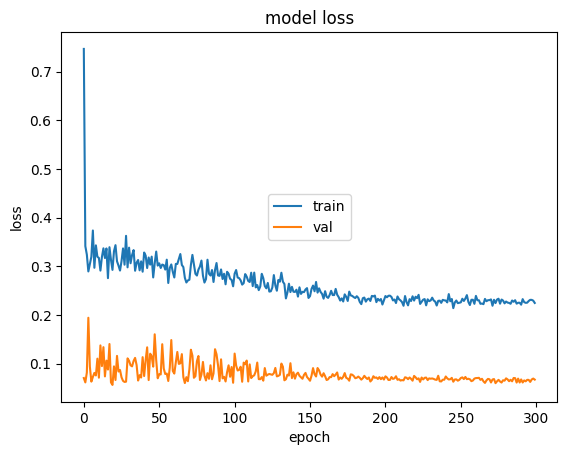

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='center')

El modelo alcanzó pérdidas similares a las del modelo anterior en ambos conjuntos de datos, ahora se realizarán las predicciones. 

In [54]:
prediccion_val = []

def prediccion_fun(data,modelo, batch_size,scaler,dif=False,dif_cant=1, Series = None , n=1):
    prediccion = [0]* (len(data))
    i=0
    for X in data:
        X = np.reshape(X,(1,1,1))
        yhat = modelo.predict(X, batch_size=batch_size,verbose=0)
        # invert scaling
        yhat = scaler.inverse_transform(yhat)
        if dif:
             # invert differencing
            yhat  = yhat + Series[(n+dif_cant*i)]
        # store
        prediccion[i]=yhat[0][0]
        i = i+1
    return prediccion
prediccion_val = prediccion_fun(x_val,model2, 1,scaler,dif=False,dif_cant=0, Series = precios_regular.values , n=entrenamiento)
prediccion_test = prediccion_fun(x_test,model2, 1,scaler,dif=False,dif_cant=0, Series = precios_regular.values , n=entrenamiento+val_prueba)

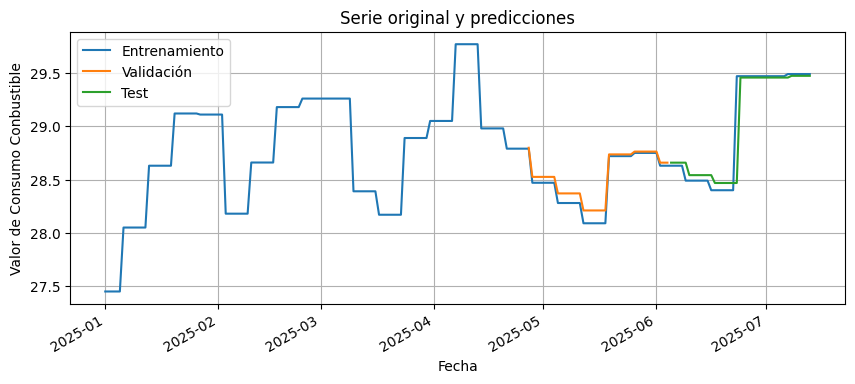

In [55]:
df_val = pd.DataFrame(prediccion_val,index=precios_regular[(entrenamiento):entrenamiento+val_prueba].index)
start_test = entrenamiento + len(df_val)
end_test = start_test + len(prediccion_test)

df_test = pd.DataFrame(prediccion_test, index=precios_regular[start_test:end_test].index)




plt.figure(figsize=(10,4))
plt.plot(precios_regular,        label='Entrenamiento')
plt.plot(df_val,    label='Validación')

plt.plot(df_test,   label='Test')

plt.title('Serie original y predicciones')
plt.xlabel('Fecha')
plt.ylabel('Valor de Consumo Conbustible')
plt.grid(True)
plt.legend(loc='upper left')

plt.gcf().autofmt_xdate()
plt.show()

In [56]:
print("Pérdida en Entrenamiento")                              # opcional, para limpiar estados previos
train_loss = model2.evaluate(
    x=x_train,
    y=y_train,
    batch_size=batch_size,
    verbose=1
)

print("\nPérdida en Validación")
val_loss = model2.evaluate(
    x=x_val,
    y=y_val,
    batch_size=batch_size,
    verbose=1
)


print("Pérdida en prueba")
val_loss = model2.evaluate(
    x=x_test,
    y=y_test,
    batch_size=batch_size,
    verbose=1
)

Pérdida en Entrenamiento
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 0.4593

Pérdida en Validación
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 0.0954
Pérdida en prueba
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0906 


El modelo muestra peores métricas con los conjuntos de validación y entrenamiento pero la pérdida con el conjunto de prueba es ligeramente superior a la del modelo anterior,  este modelo logra adaptarse un poco mejor a datos nuevos que el primero. 

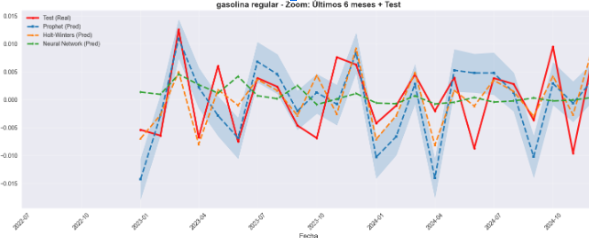

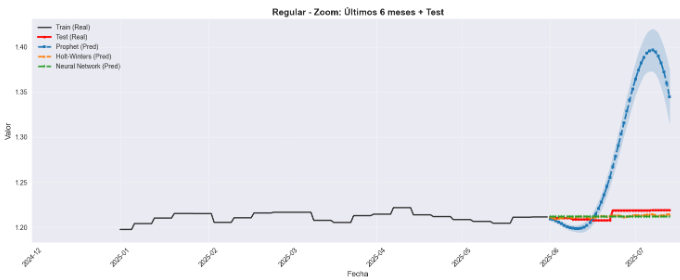

## Discusion


De todas las series trabajadas anteriormente, se seleccionaron dos: **el consumo de gasolina regular** y **el precio de la gasolina regular**.

En la primera serie se observa una tendencia clara. Al descomponerla en sus componentes, también se aprecia que es secuencial y que **no es estacionaria ni en media ni en varianza**. Por ello, se aplicó una **diferenciación** y una **transformación logarítmica** para normalizarla.

Sobre esta serie se implementaron dos modelos:

**1. Primer modelo:**
- Red neuronal secuencial con LSTM
- 50 neuronas por capa
- Optimizador adaptativo
- Función de activación **ELU (Exponential Linear Unit)**

**2. Segundo modelo:**
- LSTM con 32 neuronas por capa
- Función de activación **ELU**
- Optimizador **RMSprop (Root Mean Square Propagation)**
- Una capa **bidireccional**, la cual permite predecir considerando tanto el pasado como el futuro

Al analizar la **pérdida** de ambos modelos, se observa que la diferencia promedio entre entrenamiento y validación es de aproximadamente **0.4**, lo que indica un rendimiento similar. Sin embargo, al examinar las gráficas de predicción, se nota que el **primer modelo** ajusta mejor la serie y presenta menor pérdida, siendo el más efectivo.

Posteriormente, se realizó el análisis de la serie de **precios de gasolina regular**. Esta serie no mostró signos de no estacionariedad por lo que no se realizó ninguna transformación a esta serie.

**1. Primer modelo:**
- Función de activación **ReLU**
- Batch size de 32
- 128 neuronas por capa
- Optimizador **Adam**
- Función de pérdida **MSE**

**2. Segundo modelo:**
- Función de activación **Sigmoide**
- Mayor learning rate
- Menor dropout
- Más células de procesamiento

Los resultados mostraron que el **primer modelo** tuvo una diferencia de pérdida entre entrenamiento y validación de solo **0.10**. El **segundo modelo** mostró una diferencia mayor en la pérdida de entrenamiento y prueba, posiblemente debido a que se adapta un poco mejor a nueva información.

Lo que se busca aquí es evaluar si los modelos LSTM mejoran respecto a lo observado en el estudio anterior. Para ello se compara en la siguiente tabla su desempeño con los modelos previos:

| Modelo | Precios Gasolina Regular | Consumo Gasolina Regular |
|--------|--------------------------|--------------------------|
| LSTM |  116735.20 | 21419.02 |
| ARIMA | -430.30 | -430.30 |
| Prophet | -63.21 | -159.93 |
| Holt Winters | -336.37 | -179.45 |
| Redes Neuronales | 3373.82 | 3528.21 |

Se puede observar que el **AIC de los modelos LSTM es muy alto** y realmente no mejoró respecto a los modelos tradicionales. Sin embargo, cabe resaltar una característica importante: **el modelo predice muy bien con los datos de la serie**. De hecho, de manera visual se observa que los **LSTM mejoraron mucho** con respecto a los modelos anteriores.


En las **Grafica de Otros modelos para consumo**  y **Grafica de Precios Gasolina Regular predicciones**  se puede ver que los modelos tradicionales que se utilizaron **no llegan a ser tan precisos** como lo que debería ser en el test, contrastando mucho con lo que se logró predecir con los LSTM. 

Esto nos indica que, **si bien el AIC de los LSTM es bastante malo, tienen un buen ajuste a los datos originales**, lo que podría servir para realizar **predicciones futuras** más precisas.

## Conclusion

- Los LSTM mejoran en ajuste a los datos reales
- Los AIC y BIC de los modelos son malos pero eso no significa que los LSTM sean asi 
- Se logro tener datos mas precisos y predicciones mas certeras